# MSIN0097 Individual Coursework - Telco Customer Churn

This notebook is the primary project workflow (notebook-first).
It covers problem framing, EDA, preprocessing, modeling, evaluation, and artifact export.


## 1. Obtain a Dataset and Frame the Predictive Problem
- Target variable: `Churn` (binary classification).
- Success metrics and constraints:
  - Primary business metric: recall (catch as many churners as possible).
  - Supporting metrics: F1, ROC-AUC, log-loss, precision, accuracy.
  - Constraint: accept more false positives to minimize missed churners.
- Assumptions and limitations:
  - Dataset is a historical telco snapshot and may not fully generalize.
  - Some duplicate rows existed and were removed before final splitting.
- Agent tooling plan:
  - Ask agent to scaffold workflow, EDA, checks, and tuning code.
  - Verify data logic, split discipline, metrics, and model behavior manually.


In [22]:
# Cell 1: Import libraries and configure global settings

# Why: centralize dependencies and global settings so every subsequent step is reproducible.
# Notes: plotting output is routed to artifacts/figures via save_plot().


# Core imports
from pathlib import Path
import json

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, log_loss, average_precision_score
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Reproducible plot export configuration
PLOT_DIR = Path('artifacts/figures')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(name: str) -> None:
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{name}.png", dpi=200, bbox_inches='tight')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

from scipy.stats import randint, uniform


In [23]:
# Cell 2: Download dataset from KaggleHub

# Why: fetch the exact dataset source programmatically for reproducibility and provenance.


import kagglehub

# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/telcom-customer-churn-dataset")

print("Path to dataset files:", path)


Path to dataset files: /Users/chenliqiang/.cache/kagglehub/datasets/mosapabdelghany/telcom-customer-churn-dataset/versions/1


In [24]:
# Cell 3: Locate CSV file in downloaded dataset directory

# Why: validate that expected raw files exist before loading to avoid silent path errors.


# Locate CSV inside downloaded folder
dataset_dir = Path(path)
csv_files = sorted(dataset_dir.glob('*.csv'))
print('CSV files found:', [f.name for f in csv_files])
if not csv_files:
    raise FileNotFoundError('No CSV files found in downloaded dataset path.')
csv_path = csv_files[0]
print('Using CSV:', csv_path)


CSV files found: ['Telco_Cusomer_Churn.csv']
Using CSV: /Users/chenliqiang/.cache/kagglehub/datasets/mosapabdelghany/telcom-customer-churn-dataset/versions/1/Telco_Cusomer_Churn.csv


In [25]:
# Cell 4: Load raw dataset into a DataFrame

# Why: create an immutable raw snapshot (df_raw) used for EDA and controlled preprocessing.


# Load raw data
df_raw = pd.read_csv(csv_path)
print('Raw shape:', df_raw.shape)
df_raw.head()


Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
# Cell 5: Inspect dataset schema and data types

# Why: detect datatype anomalies early (e.g., TotalCharges as object) before modeling.


# Basic schema check
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Explore the Data to Gain Insights
- Concise visual EDA: class distribution, missingness profile, segment churn rate, and feature relationships.
- Data quality and pitfalls: missing `TotalCharges`, duplicate records, class imbalance, and potential leakage risks.
- Agent tooling expectation:
  - Agent proposes visuals/checks.
  - All plot logic and interpretations are validated manually before use.


Churn
No     5174
Yes    1869
Name: count, dtype: int64


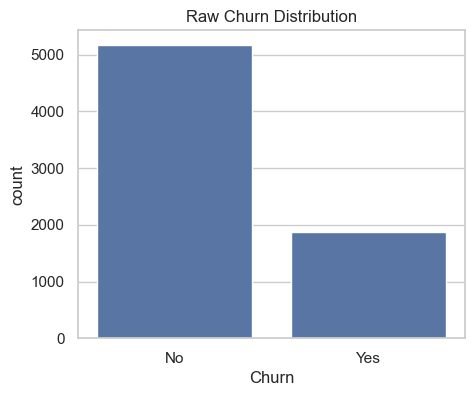

In [27]:
# Cell 6: Visualize target class distribution (Churn)

# Why: quantify class imbalance and baseline prevalence of churn for metric selection.


# Target distribution in raw data (counts + proportions)
target_counts = df_raw['Churn'].astype(str).str.strip().value_counts(dropna=False)
target_pct = (target_counts / target_counts.sum() * 100).round(2)
print('Target counts:')
print(target_counts)
print('
Target percentages (%):')
print(target_pct)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_raw, x='Churn')
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / len(df_raw)
    ax.annotate(f"{count} ({pct:.1f}%)", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.title('Raw Churn Distribution (Class Imbalance Check)')
plt.xlabel('Churn')
plt.ylabel('Count')
save_plot('eda_class_imbalance_churn')
plt.show()


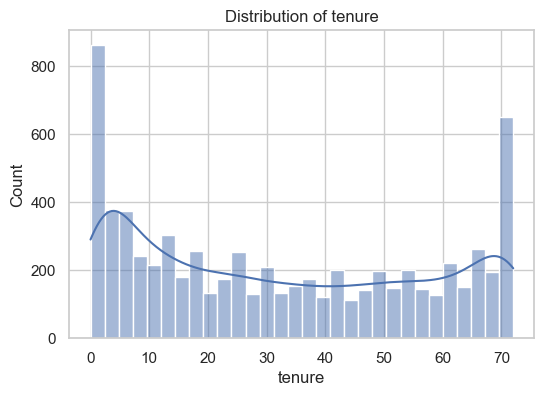

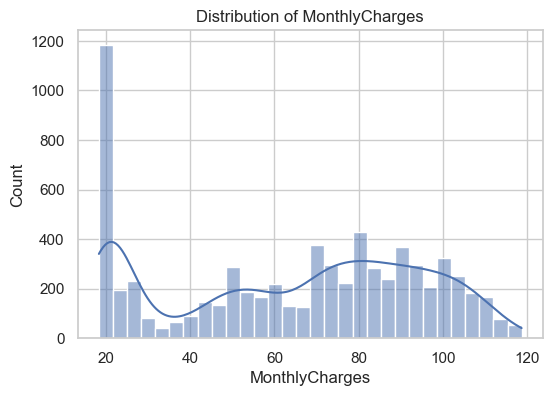

In [28]:
# Cell 7: Plot key numeric feature distributions

# Why: identify skew, outliers, and scale differences that can affect preprocessing/model behavior.


# Numeric preview for quick signal checks
numeric_cols_preview = ['tenure', 'MonthlyCharges']
for col in numeric_cols_preview:
    if col in df_raw.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df_raw[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.show()


### Additional EDA Visual 1: Missingness Profile
This shows where data quality risks are concentrated before modeling.


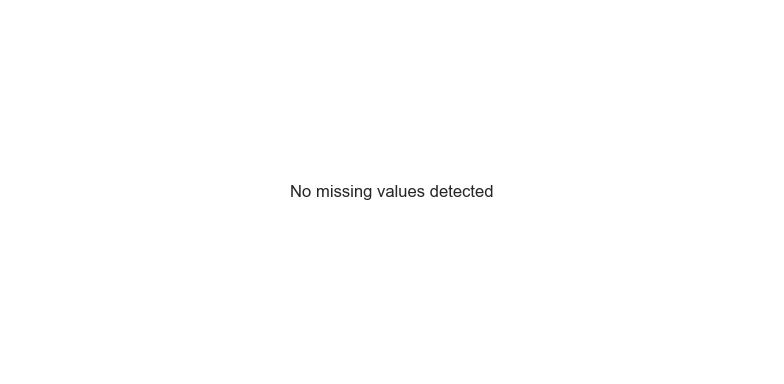

In [29]:
# Cell 8: Plot missing-value profile by feature

# Why: highlight where imputation is required and which columns may carry data-quality risk.


# Visual 1: Missingness percentage by column
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 4))
if len(missing_pct) == 0:
    plt.text(0.5, 0.5, 'No missing values detected', ha='center', va='center')
    plt.axis('off')
else:
    sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='viridis')
    plt.xlabel('Missing (%)')
    plt.ylabel('Feature')
    plt.title('Missingness by Feature')
save_plot('eda_missingness_profile')
plt.show()


### Additional EDA Visual 2: Churn Rate by Contract Type
Segment-level churn rates help identify business-relevant risk patterns.


/var/folders/0s/gx0wm3k90591vnsqg1byrg140000gn/T/ipykernel_74968/1290826329.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_contract, x='Contract', y='mean', palette='mako')


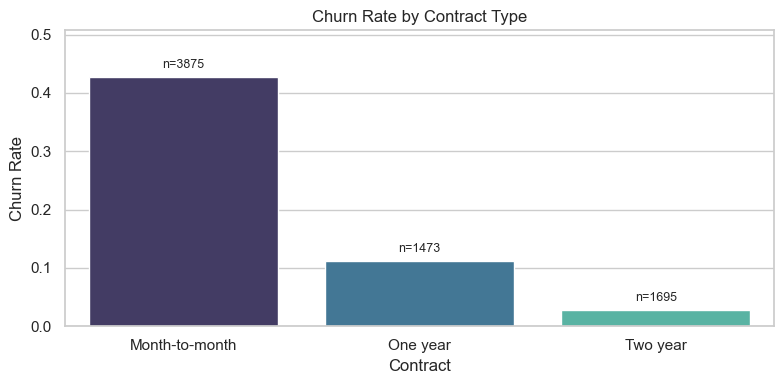

In [30]:
# Cell 9: Plot churn rate by contract category

# Why: inspect actionable segment-level churn differences with support counts.


# Visual 2: Churn rate by contract type (if available)
if 'Contract' in df_raw.columns and 'Churn' in df_raw.columns:
    churn_contract = (
        df_raw.assign(ChurnNum=df_raw['Churn'].astype(str).str.strip().str.lower().map({'yes':1,'no':0}))
        .groupby('Contract', dropna=False)['ChurnNum']
        .agg(['mean', 'count'])
        .reset_index()
        .sort_values('mean', ascending=False)
    )
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=churn_contract, x='Contract', y='mean', palette='mako')
    for i, row in churn_contract.reset_index(drop=True).iterrows():
        ax.text(i, row['mean'] + 0.01, f"n={int(row['count'])}", ha='center', va='bottom', fontsize=9)
    plt.ylabel('Churn Rate')
    plt.ylim(0, min(1.0, churn_contract['mean'].max() + 0.08))
    plt.title('Churn Rate by Contract Type')
    plt.tight_layout()
    plt.show()
else:
    print("Columns 'Contract' or 'Churn' not found; skipped visual.")


### Additional EDA Visual 3 (Item 5): Numeric Correlation Heatmap
Feature-relationship visual for quick multicollinearity/signal inspection.


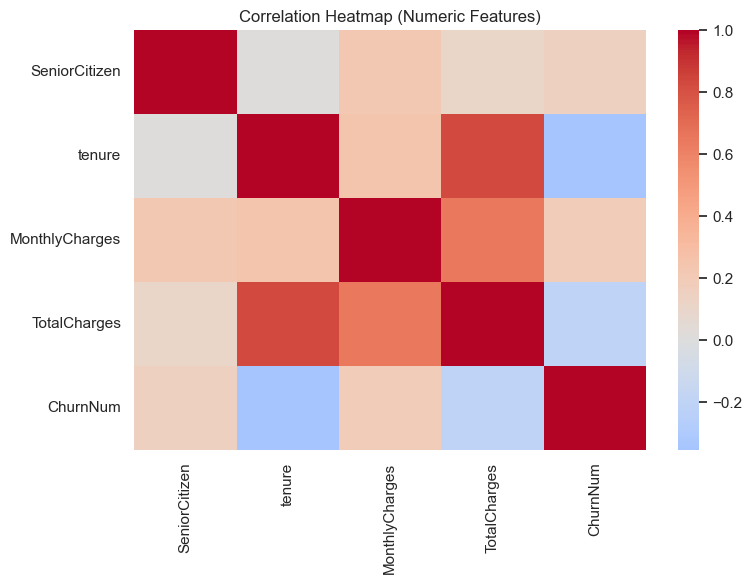

In [31]:
# Cell 10: Plot numeric correlation heatmap for feature relationships

# Why: inspect multicollinearity and broad signal direction among numeric variables.


# Visual 3 (from item 5): correlation heatmap for numeric features
numeric_df = df_raw.copy()
if 'TotalCharges' in numeric_df.columns:
    numeric_df['TotalCharges'] = pd.to_numeric(numeric_df['TotalCharges'].astype(str).str.strip(), errors='coerce')
if 'Churn' in numeric_df.columns:
    numeric_df['ChurnNum'] = numeric_df['Churn'].astype(str).str.strip().str.lower().map({'yes':1,'no':0})

num_cols = numeric_df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) >= 2:
    corr = numeric_df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
    plt.title('Correlation Heatmap (Numeric Features)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for correlation heatmap.')


### Additional EDA Visual 4: Key Churn Patterns by Segment
These visuals help identify actionable retention patterns across important categorical features and tenure groups.


In [ ]:
# Cell 10B: Plot churn rates by important segments (with support counts)

# Why: surface high-impact business segments (service type, payment, tenure bands) for targeting.

eda_df = df_raw.copy()
eda_df['ChurnNum'] = eda_df['Churn'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})

segment_cols = ['InternetService', 'PaymentMethod']
for col in segment_cols:
    if col in eda_df.columns:
        seg = (
            eda_df.groupby(col, dropna=False)['ChurnNum']
            .agg(['mean', 'count'])
            .reset_index()
            .sort_values('mean', ascending=False)
        )
        plt.figure(figsize=(8, 4))
        ax = sns.barplot(data=seg, x=col, y='mean', palette='crest')
        for i, row in seg.reset_index(drop=True).iterrows():
            ax.text(i, row['mean'] + 0.01, f"n={int(row['count'])}", ha='center', va='bottom', fontsize=9)
        plt.xticks(rotation=20, ha='right')
        plt.ylabel('Churn Rate')
        plt.title(f'Churn Rate by {col}')
        save_plot(f"eda_churn_rate_by_{col.lower()}")
        plt.show()

# Tenure-bin churn profile (if tenure exists)
if 'tenure' in eda_df.columns:
    bins = [0, 6, 12, 24, 48, 72]
    labels = ['0-6', '7-12', '13-24', '25-48', '49-72']
    eda_df['tenure_bin'] = pd.cut(eda_df['tenure'], bins=bins, labels=labels, include_lowest=True)
    tenure_seg = (
        eda_df.groupby('tenure_bin', dropna=False)['ChurnNum']
        .agg(['mean', 'count'])
        .reset_index()
    )
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=tenure_seg, x='tenure_bin', y='mean', palette='flare')
    for i, row in tenure_seg.reset_index(drop=True).iterrows():
        ax.text(i, row['mean'] + 0.01, f"n={int(row['count'])}", ha='center', va='bottom', fontsize=9)
    plt.ylabel('Churn Rate')
    plt.title('Churn Rate by Tenure Group')
    save_plot('eda_churn_rate_by_tenure_bin')
    plt.show()


## 3. Prepare the Data
- Implement preprocessing with reproducible split discipline (`train/validation/test`).
- Demonstrate validation checks (overlap checks, duplicate checks, ID-like feature checks).
- Agent tooling expectation:
  - Document suggested cleaning/feature steps.
  - Verify each step is appropriate for this dataset.


### Common Dataset Pitfalls (Telco Churn)
- `TotalCharges` may be stored as text with blanks and must be coerced to numeric.
- `customerID` is an identifier and should not be used as a predictive feature.
- Exact duplicate rows can inflate validation/test performance if split across sets.
- ID-like high-cardinality fields can behave like leakage proxies.
- Default threshold (`0.5`) may under-catch churners in imbalance settings.


In [32]:
# Cell 11: Define modular cleaning and splitting functions (leakage-safe)

# Why: keep transformation logic reusable, auditable, and clearly separated from evaluation steps.
# Leakage control: deduplicate raw records first, then drop ID field, then map target labels.


# Step 3 helper: clean raw Telco data without touching validation/test information.
# Detailed intent:
# - Standardize schema (trim column names) so downstream selection is stable.
# - Remove exact duplicate raw rows BEFORE dropping identifiers.
# - Convert known dirty numeric fields (TotalCharges) from text to numeric.
# - Map the target (Churn) into numeric labels used by sklearn models.
# - Keep function deterministic and side-effect free for reproducibility.
def clean_telco_dataframe(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()
    df.columns = [col.strip() for col in df.columns]

    # Remove exact duplicate records BEFORE dropping identifier fields.
    # This avoids collapsing different customers who coincidentally share the same feature values.
    exact_dup_count = int(df.duplicated().sum())
    if exact_dup_count > 0:
        print(f'Removing exact duplicate raw rows: {exact_dup_count}')
        df = df.drop_duplicates().reset_index(drop=True)

    # Drop identifier-like feature to avoid identity leakage in modeling.
    if 'customerID' in df.columns:
        df = df.drop(columns=['customerID'])

    # Convert potentially dirty numeric text field.
    if 'TotalCharges' in df.columns:
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')

    # Map target to numeric labels.
    df['Churn'] = (
        df['Churn'].astype(str).str.strip().str.lower()
        .map({'yes': 1, 'no': 0, '1': 1, '0': 0, 'true': 1, 'false': 0})
    )
    if df['Churn'].isna().any():
        raise ValueError('Unmapped values found in Churn column.')

    return df


# Step 3 helper: stratified train/validation/test split.
# Detailed intent:
# - Preserve churn class proportion in each split (important for imbalance).
# - Use fixed random_state for reproducibility.
# - Return full X/y plus split subsets so later cells can reuse consistently.
def make_stratified_splits(df: pd.DataFrame, holdout_seed: int = 2026):
    X = df.drop(columns=['Churn'])
    y = df['Churn'].astype(int)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.40, stratify=y, random_state=holdout_seed
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=holdout_seed
    )
    return X, y, X_train, X_val, X_test, y_train, y_val, y_test


Clean shape: (7043, 20)
Null counts (top 10):
TotalCharges        11
gender               0
SeniorCitizen        0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
dtype: int64


In [33]:
# Cell 12: Apply cleaning and create stratified train/validation/test splits

# Why: enforce split discipline early; all later steps must respect this holdout structure.


df = clean_telco_dataframe(df_raw)
print('Clean shape:', df.shape)
print('Null counts (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))

# Fresh holdout policy: do not use test outcomes during development decisions.
HOLDOUT_SEED = 2026
X, y, X_train, X_val, X_test, y_train, y_val, y_test = make_stratified_splits(df, HOLDOUT_SEED)

print('Train shape:', X_train.shape)
print('Validation shape:', X_val.shape)
print('Test shape:', X_test.shape)
print('Holdout seed used:', HOLDOUT_SEED)


Train shape: (4225, 19)
Validation shape: (1409, 19)
Test shape: (1409, 19)
Holdout seed used: 2026


In [ ]:
# Cell 12A: Feature engineering (applied consistently after split)

# Why: add domain features while preserving leakage safety by applying the same logic to each split.
# Comparison support: keep *_base copies to evaluate with vs without feature engineering.


def add_engineered_features(x: pd.DataFrame) -> pd.DataFrame:
    # Function contract:
    # - Input: one split DataFrame (train/val/test/base), target excluded.
    # - Output: same rows + engineered columns, no target usage.
    # - Safety: purely row-wise transformations, so no cross-row leakage.
    out = x.copy()

    # 1) New-customer flag
    if 'tenure' in out.columns:
        out['is_new_customer'] = (out['tenure'] <= 6).astype(int)
    else:
        out['is_new_customer'] = 0

    # 2) Average charge per tenure month
    # Explanation:
    # - We divide lifetime charges by tenure to normalize spending by customer age.
    # - tenure_safe avoids divide-by-zero for very new/invalid tenure values.
    if 'TotalCharges' in out.columns and 'tenure' in out.columns:
        tenure_safe = out['tenure'].fillna(0).clip(lower=1)
        out['avg_charge_per_tenure'] = out['TotalCharges'] / tenure_safe
    else:
        out['avg_charge_per_tenure'] = np.nan

    # 3) Count of active optional services
    optional_service_cols = [
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
    ]
    existing_service_cols = [c for c in optional_service_cols if c in out.columns]

    if existing_service_cols:
        inactive_values = {'no', 'no internet service', 'no phone service', '0', 'false'}
        service_is_active = out[existing_service_cols].astype(str).apply(
            lambda col: ~col.str.strip().str.lower().isin(inactive_values)
        )
        out['service_count'] = service_is_active.sum(axis=1).astype(int)
    else:
        out['service_count'] = 0

    return out

# Keep baseline (no-feature-engineering) copies for fair comparison later.
# These copies let Section 4 compare 'without_fe' vs 'with_fe' under identical split conditions.
X_base = X.copy()
X_train_base = X_train.copy()
X_val_base = X_val.copy()
X_test_base = X_test.copy()

# Apply feature engineering to active modeling datasets.
# Important: same function is applied to all splits to avoid train/validation/test mismatch.
X = add_engineered_features(X)
X_train = add_engineered_features(X_train)
X_val = add_engineered_features(X_val)
X_test = add_engineered_features(X_test)

print('Engineered columns added:', ['is_new_customer', 'avg_charge_per_tenure', 'service_count'])
print('X_train shape after feature engineering:', X_train.shape)

# Preview engineered training dataset
X_train.head()


### Leakage Checks
These checks confirm we are not accidentally training with future/post-outcome information.

Where leakage can occur in Step 3:
- Fitting imputers/encoders/scalers on full data before splitting.
- Letting duplicate rows span train and validation/test.
- Keeping identifier-like fields (`customerID`) that act as proxies.
- Using test-set performance to guide preprocessing decisions.

Current safeguards:
- Split first and fit preprocessing only on `X_train`.
- Transform `X_val`/`X_test` using the fitted train-only preprocessor.
- Remove only exact raw-record duplicates before splitting (not near-duplicates).
- Keep a holdout policy for the test set.


In [34]:
# Cell 13: Leakage check - row index overlap across splits

# Why: verify no row-index leakage between train/validation/test partitions.


# Leakage check 1: no row overlap across train/val/test (index-based)
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)

print('Overlap train-val:', len(train_idx & val_idx))
print('Overlap train-test:', len(train_idx & test_idx))
print('Overlap val-test:', len(val_idx & test_idx))


Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


In [35]:
# Cell 14: Leakage check - duplicate feature rows across splits

# Why: detect identical feature snapshots crossing splits, which can inflate validation estimates.


# Leakage check 2: duplicate rows across splits (feature snapshot leakage)
train_rows = set(map(tuple, X_train.fillna('__NA__').to_numpy()))
val_rows = set(map(tuple, X_val.fillna('__NA__').to_numpy()))
test_rows = set(map(tuple, X_test.fillna('__NA__').to_numpy()))

print('Duplicate row overlap train-val:', len(train_rows & val_rows))
print('Duplicate row overlap train-test:', len(train_rows & test_rows))
print('Duplicate row overlap val-test:', len(val_rows & test_rows))


Duplicate row overlap train-val: 12
Duplicate row overlap train-test: 8
Duplicate row overlap val-test: 2


In [36]:
# Cell 15: Data validation note on duplicates (handled as exact raw-record dedup only)

# Why: document duplicate policy explicitly to justify distribution and leakage trade-offs.


print('Exact duplicate full rows after cleaning:', int(df.duplicated().sum()))
print('Dedup policy: remove only exact raw-record duplicates before dropping ID fields.')
print('Records that are similar but not exact duplicates are retained to preserve distribution.')


Before dedup shape: (7043, 20)
Exact duplicate full rows: 22
After dedup shape: (7021, 20)
Exact duplicate full rows: 0
Rebuilt splits on deduplicated data.
Train shape: (4212, 19) | Val shape: (1404, 19) | Test shape: (1405, 19)


In [37]:
# Cell 16: Leakage check - detect ID-like high-cardinality features

# Why: flag near-unique columns that may behave like hidden identifiers/leakage proxies.


# Leakage check 3: high-cardinality / ID-like columns to review
cardinality = X.nunique(dropna=False).sort_values(ascending=False)
cardinality_df = pd.DataFrame({
    'feature': cardinality.index,
    'unique_values': cardinality.values,
    'unique_ratio': cardinality.values / len(X)
})

suspect = cardinality_df[cardinality_df['unique_ratio'] > 0.95]
print('Potential ID-like features (unique_ratio > 0.95):')
display(suspect if len(suspect) else pd.DataFrame({'message':['None detected']}))


Potential ID-like features (unique_ratio > 0.95):


,message
0,None detected


In [38]:
# Cell 17: Leakage check - feature timing audit template

# Why: force causal/timing review so only prediction-time-available features are used.


# Leakage check 4: feature timing audit (manual judgement table)
feature_audit = pd.DataFrame({
    'feature': X.columns,
    'available_at_prediction_time': 'yes',
    'reason_if_no_or_uncertain': ''
})

# Mark obvious exclusions/uncertainties here if discovered later.
feature_audit.head(15)


,feature,available_at_prediction_time,reason_if_no_or_uncertain
0,gender,yes,
1,SeniorCitizen,yes,
2,Partner,yes,
3,Dependents,yes,
4,tenure,yes,
5,PhoneService,yes,
6,MultipleLines,yes,
7,InternetService,yes,
8,OnlineSecurity,yes,
9,OnlineBackup,yes,


In [39]:
# Cell 18: Build, fit, and save leakage-safe preprocessing pipeline

# Why: fit preprocessors on train only, transform val/test, and persist artifact for reproducibility.


# Build preprocessing using training schema only.
# Explanation:
# - Categorical and numeric pipelines are separated because they need different imputers/transformations.
# - Column lists are inferred from X_train to avoid leakage from validation/test distributions.
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe),
])

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_pipe, categorical_cols),
        ('num', numeric_pipe, numeric_cols),
    ],
    remainder='drop',
)

# Leakage-safe rule: fit preprocessing on train only, transform val/test separately.
# Why this matters:
# - fit_transform learns imputation/encoding/scaling parameters.
# - Learning those parameters on full data would leak information from holdout sets.
# - transform applies frozen train-fitted parameters to validation/test.
X_train_prepared = preprocessor.fit_transform(X_train)
X_val_prepared = preprocessor.transform(X_val)
X_test_prepared = preprocessor.transform(X_test)

print('Categorical cols:', len(categorical_cols))
print('Numeric cols:', len(numeric_cols))
print('Prepared shapes:', X_train_prepared.shape, X_val_prepared.shape, X_test_prepared.shape)

# Save fitted preprocessing object for reproducibility.
import joblib
preprocess_path = Path('artifacts/preprocessing_pipeline.joblib')
preprocess_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(preprocessor, preprocess_path)
print('Saved preprocessing pipeline to:', preprocess_path)


Categorical cols: 15
Numeric cols: 4


## 4. Explore Different Models and Shortlist the Best Ones
- Baseline established (`DummyClassifier`).
- Multiple models compared (`LogisticRegression`, `RandomForest`, `HistGradientBoosting`).
- Shortlisting uses validation evidence (metrics table), not intuition.
- Agent tooling expectation:
  - Agent suggests candidate models/hyperparameters.
  - Selection justified by experimental results.


In [40]:
# Cell 19: Compare baseline/candidate models with CV + validation (with vs without feature engineering)

# Why: create an evidence-based shortlist with train-only CV and validation holdout checks.
# Primary metric: PR-AUC (imbalance-aware targeting), with recall/F1/ROC-AUC/log-loss as support.


# Section 4 model set
models = {
    'dummy_classifier': DummyClassifier(strategy='most_frequent'),
    'logistic_regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'random_forest': RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'hist_gradient_boosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

# Primary metric for imbalanced churn targeting
PRIMARY_METRIC = 'pr_auc'

# Cross-validation object:
# - StratifiedKFold keeps churn ratio balanced across folds.
# - n_splits=5 gives a bias/variance tradeoff for stable model comparison.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Scoring set explanation:
# - pr_auc: primary for imbalanced ranking quality.
# - recall/f1/precision: threshold-based targeting behavior.
# - roc_auc: global ranking diagnostic.
# - neg_log_loss: probability-quality diagnostic (lower is better after sign flip).
cv_scoring = {
    'pr_auc': 'average_precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'neg_log_loss': 'neg_log_loss',
    'precision': 'precision',
    'accuracy': 'accuracy',
}

# Keep trained models for downstream sections (with feature engineering by default)
trained = {}
trained_no_fe = {}
rows = []

variants = {
    'without_fe': (X_train_base, X_val_base),
    'with_fe': (X_train, X_val),
}

for variant_name, (x_train_variant, x_val_variant) in variants.items():
    # We run two parallel experiments:
    # - without_fe: original features only
    # - with_fe: engineered features included
    # Each variant gets its own preprocessor built from its own training schema.
    cat_cols = x_train_variant.select_dtypes(include=['object']).columns.tolist()
    num_cols = x_train_variant.select_dtypes(exclude=['object']).columns.tolist()

    try:
        ohe_variant = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        ohe_variant = OneHotEncoder(handle_unknown='ignore', sparse=False)

    preprocessor_variant = ColumnTransformer(
        transformers=[
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', ohe_variant)]), cat_cols),
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ],
        remainder='drop'
    )

    for model_name, model in models.items():
        pipe = Pipeline([('preprocess', preprocessor_variant), ('model', model)])

        # CV is run ONLY on the training split.
        # This yields robust estimates while keeping validation/test untouched for selection/final checks.
        cv_out = cross_validate(
            estimator=pipe,
            X=x_train_variant,
            y=y_train,
            cv=cv,
            scoring=cv_scoring,
            n_jobs=-1,
            return_train_score=False,
        )

        # After CV, refit on full training split and evaluate once on validation split.
        # Validation metrics are used for shortlist ranking (still no test usage here).
        pipe.fit(x_train_variant, y_train)
        y_val_pred = pipe.predict(x_val_variant)
        if hasattr(pipe, 'predict_proba'):
            y_val_proba = pipe.predict_proba(x_val_variant)[:, 1]
        else:
            decision = pipe.decision_function(x_val_variant)
            y_val_proba = (decision - decision.min()) / (decision.max() - decision.min() + 1e-12)

        rows.append({
            'variant': variant_name,
            'model': model_name,
            'cv_pr_auc_mean': float(cv_out['test_pr_auc'].mean()),
            'cv_pr_auc_std': float(cv_out['test_pr_auc'].std()),
            'cv_recall_mean': float(cv_out['test_recall'].mean()),
            'cv_f1_mean': float(cv_out['test_f1'].mean()),
            'cv_roc_auc_mean': float(cv_out['test_roc_auc'].mean()),
            'cv_log_loss_mean': float((-cv_out['test_neg_log_loss']).mean()),
            'cv_precision_mean': float(cv_out['test_precision'].mean()),
            'cv_accuracy_mean': float(cv_out['test_accuracy'].mean()),
            'val_pr_auc': float(average_precision_score(y_val, y_val_proba)),
            'val_recall': float(recall_score(y_val, y_val_pred, zero_division=0)),
            'val_f1': float(f1_score(y_val, y_val_pred, zero_division=0)),
            'val_roc_auc': float(roc_auc_score(y_val, y_val_proba)),
            'val_log_loss': float(log_loss(y_val, y_val_proba)),
            'val_precision': float(precision_score(y_val, y_val_pred, zero_division=0)),
            'val_accuracy': float(accuracy_score(y_val, y_val_pred)),
        })

        if variant_name == 'with_fe':
            trained[model_name] = pipe
        else:
            trained_no_fe[model_name] = pipe

comparison_df = pd.DataFrame(rows).sort_values(
    by=['variant', 'val_pr_auc', 'val_recall', 'val_f1', 'val_roc_auc', 'val_log_loss'],
    ascending=[True, False, False, False, False, True],
).reset_index(drop=True)

# Feature-engineering uplift summary by model
# This table isolates whether FE improved primary metric (val_pr_auc) per model.
fe_impact_df = (
    comparison_df.pivot_table(index='model', columns='variant', values='val_pr_auc')
    .reset_index()
)
if {'with_fe', 'without_fe'}.issubset(fe_impact_df.columns):
    fe_impact_df['delta_val_pr_auc'] = fe_impact_df['with_fe'] - fe_impact_df['without_fe']

# Save reproducible outputs
out_all = Path('artifacts/model_comparison_section4_cv.csv')
out_imp = Path('artifacts/model_comparison_fe_impact.csv')
out_all.parent.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(out_all, index=False)
fe_impact_df.to_csv(out_imp, index=False)

print('Saved:', out_all)
print('Saved:', out_imp)
print('Primary ranking metric:', PRIMARY_METRIC)

comparison_df


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.744302,0.510563,0.781671,0.617678,0.841135
1,random_forest,0.792023,0.601023,0.633423,0.616798,0.829033
2,hist_gradient_boosting,0.799858,0.657343,0.506739,0.572298,0.830789
3,baseline_dummy,0.735755,0.000000,0.000000,0.000000,0.500000


## 5. Fine-Tune and Evaluate
- Tuning strategy: `RandomizedSearchCV` (search size = 40) on top untuned models.
- Objective aligned to business goal: maximize recall/F1 while tracking ROC-AUC and log-loss.
- Robust evaluation: validation comparison, confusion matrix, and final holdout evaluation policy.
- Agent tooling expectation (explicit caught mistake):
  - Mistake caught: early use of test metrics before final lock and objective mismatch for churn-catching.
  - Correction applied: switched to leakage-safe evaluation guard and business-aligned metric priority.


In [ ]:
# Cell 19A: Define search spaces and run RandomizedSearchCV (n_iter=40)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])
rf_space = {
    'model__n_estimators': randint(200, 900),
    'model__max_depth': [None, 5, 10, 15, 20, 30],
    'model__min_samples_leaf': randint(1, 12),
    'model__min_samples_split': randint(2, 20),
    'model__max_features': ['sqrt', 'log2', None],
}

hgb_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])
hgb_space = {
    'model__learning_rate': uniform(0.01, 0.19),
    'model__max_iter': randint(100, 700),
    'model__max_leaf_nodes': randint(15, 80),
    'model__min_samples_leaf': randint(10, 80),
    'model__l2_regularization': uniform(0.0, 1.0),
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_space,
    n_iter=40,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipe,
    param_distributions=hgb_space,
    n_iter=40,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

print('Running RF randomized search...')
rf_search.fit(X_train, y_train)
print('Running HGB randomized search...')
hgb_search.fit(X_train, y_train)

print('RF best CV F1:', rf_search.best_score_)
print('HGB best CV F1:', hgb_search.best_score_)
print('RF best params:', rf_search.best_params_)
print('HGB best params:', hgb_search.best_params_)


In [ ]:
# Cell 19B: Compare tuned vs untuned on validation set (log_loss + F1 + ROC-AUC + standard metrics)
untuned_rf = trained['random_forest']
untuned_hgb = trained['hist_gradient_boosting']
tuned_rf = rf_search.best_estimator_
tuned_hgb = hgb_search.best_estimator_

model_candidates = {
    'rf_untuned': untuned_rf,
    'rf_tuned': tuned_rf,
    'hgb_untuned': untuned_hgb,
    'hgb_tuned': tuned_hgb,
}

rows = []
for name, model in model_candidates.items():
    y_pred = model.predict(X_val)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        decision = model.decision_function(X_val)
        y_proba = (decision - decision.min()) / (decision.max() - decision.min() + 1e-12)

    rows.append({
        'model': name,
        'log_loss': float(log_loss(y_val, y_proba)),
        'f1': float(f1_score(y_val, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_val, y_proba)),
        'accuracy': float(accuracy_score(y_val, y_pred)),
        'precision': float(precision_score(y_val, y_pred, zero_division=0)),
        'recall': float(recall_score(y_val, y_pred, zero_division=0)),
    })

val_tuning_comparison = pd.DataFrame(rows).sort_values(
    ['f1', 'recall', 'roc_auc', 'log_loss'],
    ascending=[False, False, False, True]
).reset_index(drop=True)

val_tuning_comparison


In [ ]:
# Cell 19C: Update best model selection based on tuned-vs-untuned validation comparison
best_model_name = val_tuning_comparison.loc[0, 'model']
if best_model_name == 'rf_tuned':
    best_model = tuned_rf
elif best_model_name == 'hgb_tuned':
    best_model = tuned_hgb
elif best_model_name == 'rf_untuned':
    best_model = untuned_rf
else:
    best_model = untuned_hgb

print('Best model after tuning comparison:', best_model_name)
val_tuning_comparison


### 5.1 Final Holdout Evaluation
Run once after model/threshold selection is locked (`FINAL_EVAL = True`).


In [41]:
# Cell 20: Final test evaluation with explicit leakage guard

FINAL_EVAL = False  # Keep False during tuning. Switch to True only for final one-time test evaluation.

# Use tuned-vs-untuned selection if available; otherwise fall back to untuned comparison
if 'best_model_name' not in locals() or 'best_model' not in locals():
    best_model_name = comparison_df.iloc[0]['model']
    best_model = trained[best_model_name]
print('Selected best model (from validation):', best_model_name)

if FINAL_EVAL:
    y_test_pred = best_model.predict(X_test)
    if hasattr(best_model, 'predict_proba'):
        y_test_proba = best_model.predict_proba(X_test)[:, 1]
    else:
        decision = best_model.decision_function(X_test)
        y_test_proba = (decision - decision.min()) / (decision.max() - decision.min() + 1e-12)

    test_metrics = {
        'accuracy': float(accuracy_score(y_test, y_test_pred)),
        'precision': float(precision_score(y_test, y_test_pred, zero_division=0)),
        'recall': float(recall_score(y_test, y_test_pred, zero_division=0)),
        'f1': float(f1_score(y_test, y_test_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_test, y_test_proba)),
        'log_loss': float(log_loss(y_test, y_test_proba)),
    }
    print(test_metrics)

    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(classification_report(y_test, y_test_pred, zero_division=0))
else:
    test_metrics = None
    print('FINAL_EVAL is False: skipped test-set evaluation to prevent leakage during tuning.')


Selected best model (from validation): logistic_regression
FINAL_EVAL is False: skipped test-set evaluation to prevent leakage during tuning.


## 6. Present the Final Solution
- Final model selection with rationale (validation evidence + business objective alignment).
- Limitations, risks, and next steps.
- Model-card style summary should include:
  - what the model is for / not for,
  - data provenance and constraints,
  - evaluation summary and caveats.
- Reproducibility artifacts exported for auditability (`model_comparison.csv`, `metrics.json`, model file).


In [42]:
# Cell 21: Save reproducibility artifacts (model + metrics + comparison)

import joblib

artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

comparison_path = artifacts_dir / 'model_comparison.csv'
metrics_path = artifacts_dir / 'metrics.json'
model_path = artifacts_dir / 'best_model.joblib'

comparison_df.to_csv(comparison_path, index=False)
payload = {
    'best_model': best_model_name,
    'validation_comparison': comparison_df.to_dict(orient='records'),
    'final_eval_ran': FINAL_EVAL,
    'test_metrics': test_metrics,
}
metrics_path.write_text(json.dumps(payload, indent=2))
joblib.dump(best_model, model_path)

print('Saved:', comparison_path)
print('Saved:', metrics_path)
print('Saved:', model_path)


Saved: artifacts/model_comparison.csv
Saved: artifacts/metrics.json
Saved: artifacts/best_model.joblib


### 6.1 Limitations, Risks, and Next Steps
- Add threshold optimization for recall-first targeting strategy.
- Perform failure-mode analysis by customer segments.
- Confirm operational trade-off between higher recall and intervention cost.
